In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as intg
from IPython.display import clear_output

In [2]:
#calculating the number of reaction sites: NSA_Pt
A_Pt=1*(10**-4)  #area of 1 cm² in m²
SD_Pt111=1.52*(10**15)*10**4  #atoms/m²
NSA_Pt=A_Pt*SD_Pt111 #absolute number of reaction sites present in 1 cm² of catalyst

In [3]:
M_F=18.998E-3  #molar mass of fluoride in kg/mol
h_memb_117=183E-6

#the data in the loaded file was extracted from a diagram in the literature
FER_data=np.loadtxt("./Laconti_FER.txt") #[0:6] 1/T, [6:12] FER in µg/hr/cm², [12:14] x-values regression line, [14:16] y-values regression line

#the fluoride-emissions are given in µg/hr/cm² -> conversion to mol/l/s
FER_data[6:12]=FER_data[6:12]*10**4/(M_F*h_memb_117*3600*10**9*1000)
FER_data[14:16]=FER_data[14:16]*10**4/(M_F*h_memb_117*3600*10**9*1000)

In [12]:
#assignment of functions "rxn", "gas_trans" and "deg_rate"

#constants
m_H=2*1.66e-27  #mass of H2 in kg
m_O=32*1.66e-27  #mass of O2 in kg
m_H2O=18*1.66e-27  #mass of H2O in kg
M_H2O=18e-3  #molar mass of water in kg/mol
density_H2O=980  #density of water in kg/m³; changes with temperature, therefore this value as a compromise
EW=1.1  #equivalent weight of Nafion in kg/mol

kbT=1.38e-23  #Boltzmann constant in J/K
R=8.314  #gas constant in J/mol/K
N_A=6.022e23  #Avogadro constant in 1/mol
F=9.648e4  #Faraday constant in As/mol

T_0=1100  #the temperature in K at which the sticking coefficients were meassured
S_H2_0=0.05  #sticking coefficient for hydrogen at 1100 K
S_O2_0=0.02  #sticking coefficient for oxygen at 1100 K

h_decay=20e-9  #decay length of *OH in m, from 10.1149/1.3581040
V_decay=h_decay*1e-7

#this function takes T and curden and outputs values concerning H2 and O2
def gas_trans(T,curden,P_cat,P_an,h_memb):
    P_cat_H2=[P_cat]
    P_an_O2=[P_an]
#     i=0
#     while i<10:
#         #hydrogen and oxygen pressure at cathode and anode respectively
#         P_cat_H2.append(P_cat+24*(4.65e-14*P_cat_H2[i]+2e-14*(P_cat_H2[i]-P_an_O2[i]))*curden/(4.65e-14*P_cat_H2[i]))
#         P_an_O2.append(P_an+28*curden)
#         i+=1
    
    #formation rates
    f_H2=curden/(2*F)  #hydrogen formation rate in mol/m²*s
    f_O2=curden/(4*F)  #oxygen formation rate in mol/m²*s
    
    #water speed through the membrane
    v_H2O=(-0.332*np.log10(curden)+5.59)*M_H2O*curden/(2*F*density_H2O)  #velocity of water in m/s; depending on current density
    v_H2O=v_H2O*h_memb/(178e-6)
    
    #diffusion (dif_coeff from 10.1016/j.ijhydene.2011.05.127)
    dif_coeff_H2=2.51e-05*np.exp(-16.51e3/(R*T))  #diffusion coefficient in m²/s
    dif_coeff_O2=1.90e-05*np.exp(-18.38e3/(R*T))
    sol_H2=0.72e-6  #solubility in mol/m³*Pa
    sol_O2=0.8e-6
    s_O2=sol_O2*P_an/1000  #solubility of O2 in Nafion in mol/l
    flux_dif_H2=dif_coeff_H2*sol_H2*P_cat_H2[-1]/h_memb  #diffusion flux in mol/m²*s
    flux_dif_O2=dif_coeff_O2*sol_O2*P_an_O2[-1]/h_memb
    #flux_dif_H2=4.65e-14*P_cat_H2[-1]/h_memb
    #flux_dif_O2=2e-14*P_an_O2[-1]/h_memb
        
    #drag
    drag_coeff=0.0134*T+0.03  #dimensionless drag coefficient
    c_H2O=40e3  #water concentration in Nafion in mol/m³
    flux_drag_H2=-0.13*np.log10(curden)*drag_coeff*P_cat_H2[-1]*sol_H2/(F*c_H2O)  #drag flux in mol/m²*s
    flux_drag_O2=0.13*np.log10(curden)*drag_coeff*P_an_O2[-1]*sol_O2/(F*c_H2O)
        
    #differential pressure
    flux_dp_H2=2e-14*(P_cat_H2[-1]-P_an_O2[-1])/h_memb  #dp flux in mol/m²*s
    flux_dp_O2=2e-14*(P_an_O2[-1]-P_cat_H2[-1])/h_memb
            
    #total flux
    flux_H2=flux_dif_H2+flux_dp_H2+flux_drag_H2  #total hydrogen flux in mol/m²*s
    flux_O2=flux_dif_O2+flux_dp_O2+flux_drag_O2  #total oxygen flux in mol/m²*s
    if flux_H2>f_H2:
        flux_H2=f_H2  #more H2 permeating than being created not possible
    if flux_O2>f_O2:
        flux_O2=f_O2  #more O2 permeating than being created not possible
    if flux_O2<0:
        flux_O2=0
        
    #ratios
    H2_in_O2=100*flux_H2/(flux_H2+f_O2)
    O2_in_H2=100*flux_O2/(flux_O2+f_H2)
    alpha=f_H2/(flux_O2+f_H2)
    
    #calculation of H2 and O2 source terms and concentrations
    r_H2=f_H2/(h_cat*1000)  #H2 rate in mol/l/s 
    r_O2=flux_O2/(h_memb*1000)  #O2 rate in mol/l/s
    
    c_H2=sol_H2*P_cat/1000  #H2 concentration in mol/l; set to the solubility because of massive H2 abundance
    c_O2=flux_O2/(v_H2O*1000)  #O2 concentration in mol/l
    if c_O2>s_O2:
        c_O2=s_O2  #concentration can't exceed solubility
    if c_O2<0:
        c_O2=0
    
    return alpha

#Defining the reaction network
def rxn(Z,t):    
    #reaction rates
    r1 = 2*Z_S_H*A_Pt*S_H2*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)         # H2_g -> 2H_a
    r_1= 2*k_1*((Z[0]/NSA_Pt)**2)                                   # H2_g <- 2H_a
    r2 = 2*Z_S_O*A_Pt*S_O2*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)         # O2_g -> 2O_a
    r_2= 2*k_2*((Z[1]/NSA_Pt)**2)                                   # O2_g <- 2O_a
    r3 = k3*(Z[0]/NSA_Pt)*(Z[1]/NSA_Pt)                             # H_a + O_a -> OH_a
    r_3= k_3*(Z[2]/NSA_Pt)*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)         # H_a + O_a <- OH_a
    r4 = k4*(Z[0]/NSA_Pt)*(Z[2]/NSA_Pt)                             # H_a + OH_a -> H2O_a
    r_4= k_4*(Z[3]/NSA_Pt)*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)         # H_a + OH_a <- H2O_a
    r5 = k5*((Z[2]/NSA_Pt)**2)                                      # OH_a + OH_a -> H2O_a + O_a 
    r_5= k_5*(Z[3]/NSA_Pt)*(Z[1]/NSA_Pt)                            # OH_a + OH_a <- H2O_a + O_a
    r6 = k6*(Z[2]/NSA_Pt)                                           # OH_a -> OH*
    r7 = k7*(Z[3]/NSA_Pt)                                           # H2O_a -> H2O_g
    r8 = k8*(Z[4]/(N_A*V_decay*1000))*c_COOH                        # OH* + COOH -> products, in mol/l/s
    
    if surf_reac==True:
        r9 = k9*((c_COOH*N_A*h_cat*1e-7*1000)/NSA_Pt)*(Z[2]/NSA_Pt)  # OH_a + COOH_a -> products, in 1/s
    else:
        r9 = 0
    
    #change in concentration
    dd0dt = +r1+r_3+r_4-r_1-r3-r4            #H_a
    dd1dt = +r2+r_3+r5-r_2-r3-r_5            #O_a
    dd2dt = +r3+r_4+2*r_5-r_3-r4-2*r5-r6-r9  #OH_a
    dd3dt = +r4+r5-r_4-r_5-r7                #H2O_a
    dd4dt = +r6-(r8*N_A*V_decay*1000)        #OH*
    dd5dt = +r7                              #H2O_g
    dd6dt = +r8                              #attacks
    dd7dt = +r9/(N_A*h_cat*1e-7*1000)        #surface reactions
           
    #    Z[H_a,   O_a,   OH_a,  H2O_a, OH*,   H2O_g,attacks,surf_reac]
    return[dd0dt, dd1dt, dd2dt, dd3dt, dd4dt, dd5dt, dd6dt, dd7dt]

def deg_rate(T,curden,P_cat,P_an,h_memb,E_d_OH,E_surf_reac):
    #impingement rates f(T,curden,P_cat,P_an,h_memb)
    global Z_S_H, Z_S_O
    if alpha_var==True:  #this if clause is only used for replication of Hellsing; Desorption vs. alpha
        Z_S_H=(alpha*P_cat/m_H)*np.sqrt(m_H/(2*np.pi*kbT*T))  #impingement rate of hydrogen at temperature T in 1/s/m²
        Z_S_O=((P_cat-alpha*P_cat)/m_O)*np.sqrt(m_O/(2*np.pi*kbT*T))  #impingement rate of oxygen at temperature T in 1/s/m²
    else:
        Z_S_H=(gas_trans(T,curden,P_cat,P_an,h_memb)*P_cat/m_H)*np.sqrt(m_H/(2*np.pi*kbT*T))  #impingement rate of hydrogen at temperature T in 1/s/m²
        Z_S_O=((P_cat-gas_trans(T,curden,P_cat,P_an,h_memb)*P_cat)/m_O)*np.sqrt(m_O/(2*np.pi*kbT*T))  #impingement rate of oxygen at temperature T in 1/s/m²    
    #sticking coefficients f(T)
    global S_H2, S_O2
    S_H2=(S_H2_0*T_0)/T  #sticking coefficient of hydrogen at temperature T
    S_O2=(S_O2_0*T_0)/T  #sticking coefficient of oxygen at temperature T
    
    #reaction constants f(T)
    global k_1, k_2, k3, k_3, k4, k_4, k5, k_5, k6, k7, k8, k9
    v=10**13  #assumed preexponential factor in s**-1
    E=[0.7,2.5,0.35,0.345,0,0.975,0,0.98,1,0.42]  #from https://doi.org/10.1016/0021-9517(91)90258-6
    #E=[0.7,2.5,0.96,0.9,0.21,0.68,0.13,0.33,1,0.34]  #from https://doi.org/10.1021/ja003576x
    #E=[0.7,2.5,0.559,1.247,0.688,1.075,0.774,0.43,1,0.43]  #from https://doi.org/10.1016/0039-6028(90)90217-V
    #E=[0.7,2.5,0.35,0.9,0.688,1.075,0.774,0.43,1,0.43]
    
    E_d_H2=E[0]*1.60*(10**-19)  #all activation energies get converted to J
    k_1=v*np.exp(-E_d_H2/(kbT*T))  #reaction constant for H2 desorption in s**-1
    E_d_O2=E[1]*1.60*(10**-19)
    k_2=v*np.exp(-E_d_O2/(kbT*T))  #reaction constant for O2 desorption in s**-1
    E_f_OH=E[2]*1.60*(10**-19)
    k3=v*np.exp(-E_f_OH/(kbT*T))  #reaction constant for OH formation in s**-1
    E_dec_OH=E[3]*1.60*(10**-19)
    k_3=v*np.exp(-E_dec_OH/(kbT*T))  #reaction constant for OH decomposition in s**-1
    E_f1_H2O=E[4]*1.60*(10**-19)
    k4=v*np.exp(-E_f1_H2O/(kbT*T))  #reaction constant for H2O formation via route 1 in s**-1
    E_dec1_H2O=E[5]*1.60*(10**-19)
    k_4=v*np.exp(-E_dec1_H2O/(kbT*T))  #reaction constant for H2O decomposition via route 1 in s**-1
    E_f2_H2O=E[6]*1.60*(10**-19)
    k5=v*np.exp(-E_f2_H2O/(kbT*T))  #reaction constant for H2O formation via route 2 in s**-1
    E_dec2_H2O=E[7]*1.60*(10**-19)
    k_5=v*np.exp(-E_dec2_H2O/(kbT*T))  #reaction constant for H2O decomposition via route 2 in s**-1
    E_d_OH=E_d_OH*1.60*(10**-19)
    k6=v*np.exp(-E_d_OH/(kbT*T))  #reaction constant for OH desorption in s**-1
    E_d_H2O=E[9]*1.60*(10**-19)
    k7=v*np.exp(-E_d_H2O/(kbT*T))  #reaction constant for H2O desorption in s**-1
    k8=1.35E7*np.exp(-6.5E3/(R*T))   # OH* + COOH -> products
    k9=v*np.exp(-E_surf_reac*1.6e-19/(kbT*T))  #surface reaction constant in s**-1
    
    #executing rxn
    t = np.linspace(0,600,1000)
    t_step = t[1]-t[0]
    Z0=[0,0,0,0,0,0,0,0]
    conc=intg.odeint(rxn, Z0, t, rtol=4.0E-8, atol=1.0E-11)
    
    attack_rate=np.diff(conc[:,6])[-1]/t_step+np.diff(conc[:,7])[-1]/t_step
    return [attack_rate, conc]

H Bedeckung bei Konstanz: 0.9999805221996028
O Bedeckung bei Konstanz: 1.9477406057985616e-05
OH Bedeckung bei Konstanz: 9.797008954580228e-11


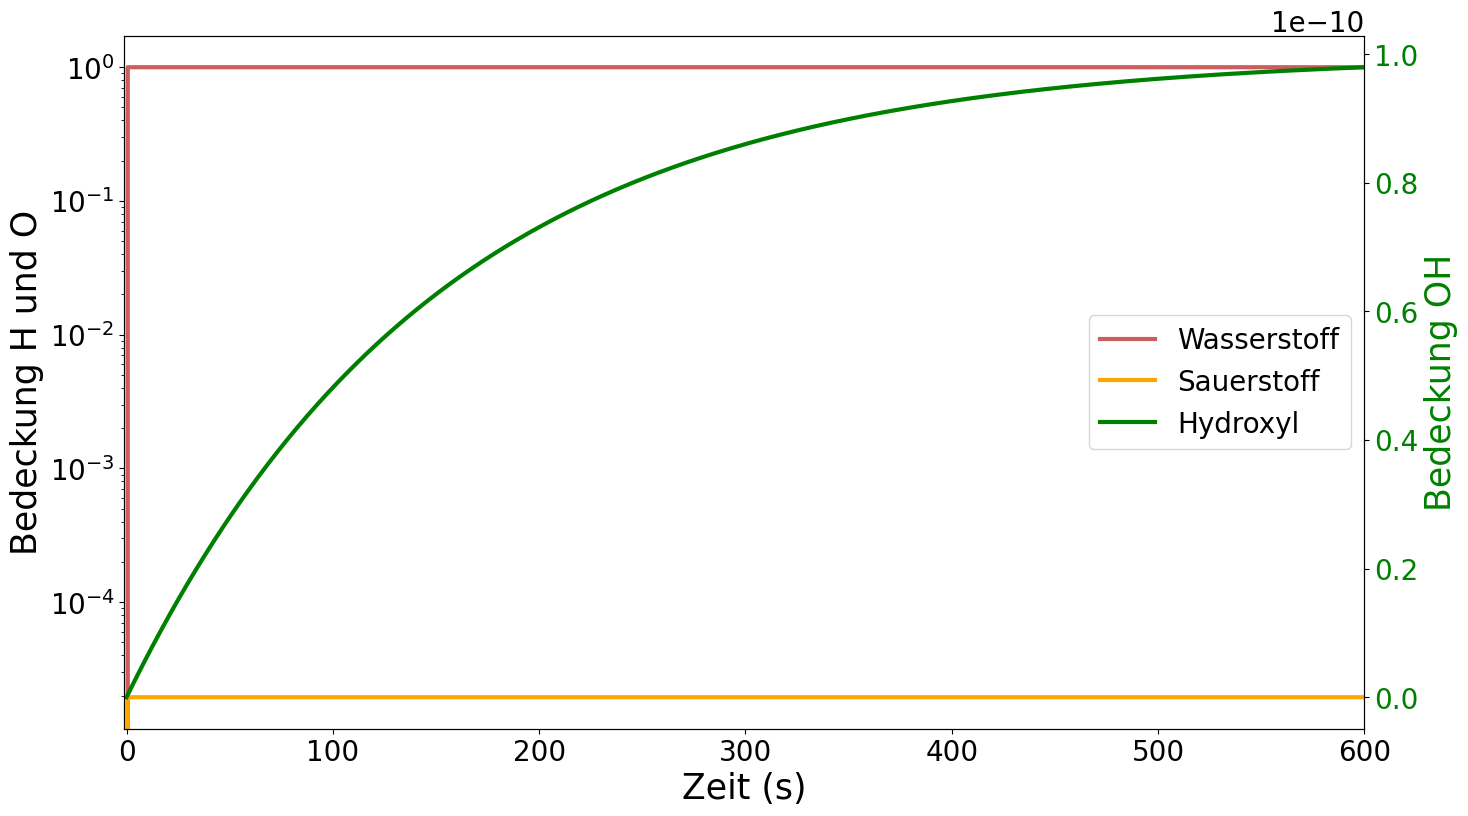

In [6]:
#temporal dependance of species
#parameters
alpha_var=False  #always False except for Desorption vs. alpha
T=273.15+60      #temperature in K
curden=10800     #current density in A/m²
P_cat=10e5        #cathode pressure in Pa
P_an=10e5         #anode pressure in Pa
h_memb=183e-5    #membrane thickness in m
h_cat=10e-6      #cathode thickness in m
h_an=10e-6       #anode thickness in m
c_COOH=1.17      #concentration of COOH-endgroups in mol/l
E_d_OH=1         #OH-desorption activation energy in eV
surf_reac=False   #with or without surface reaction
E_surf_reac=0.3  #activation energy of surface reaction in eV

#executing deg_rate
conc=deg_rate(T,curden,P_cat,P_an,h_memb,E_d_OH,E_surf_reac)[1]

print("H Bedeckung bei Konstanz:",conc[-1,0]/NSA_Pt)
print("O Bedeckung bei Konstanz:",conc[-1,1]/NSA_Pt)
print("OH Bedeckung bei Konstanz:",conc[-1,2]/NSA_Pt)
#plotting the data
plt.rc("lines", lw=3)
plt.rc("font", size=20)
fig, ax1=plt.subplots(figsize=(16,9))
ax1.plot(np.linspace(0,600,1000), conc[:,0]/NSA_Pt, color="indianred", label="Wasserstoff")
ax1.plot(np.linspace(0,600,1000), conc[:,1]/NSA_Pt, color="orange", label="Sauerstoff")
ax1.plot([0,0],[0,0], color="green", label="Hydroxyl")
ax1.set_ylabel("Bedeckung H und O", fontsize=25)
ax1.set_xlabel("Zeit (s)", fontsize=25)
plt.legend(loc="right")
plt.yscale("log")
plt.xlim(-1,600)
ax2=ax1.twinx()
ax2.plot(np.linspace(0,600,1000), conc[:,2]/NSA_Pt, color="green")
ax2.set_ylabel("Bedeckung OH", color="green", fontsize=25)
plt.yticks(color="green")
plt.show()

In [10]:
#alpha dependance of Desorption rates; recreation of Hellsing et al.
# !!! requires r8=0 !!!
#parameters
alpha_var=True   #always False except for Desorption vs. alpha
alpha_array=np.linspace(0,1,100)
T=1200           #temperature in K
curden=10800     #current density in A/m²
P_cat=13.3       #cathode pressure in Pa; 100 mTorr = 13.3 Pa
P_an=13.3        #anode pressure in Pa; 100 mTorr = 13.3 Pa
h_memb=183e-5    #membrane thickness in m
h_cat=10e-6      #cathode thickness in m
h_an=10e-6       #anode thickness in m
c_COOH=1.17      #concentration of COOH-endgroups in mol/l
E_d_OH=1         #OH-desorption activation energy in eV
surf_reac=False   #with or without surface reaction
E_surf_reac=0.3  #activation energy of surface reaction in eV

#function execution
# 1. creating a list for each set of parameters
conc=[]
# 2. running the function deg_rate() with each set of parameters; the function only takes single values not lists or arrays, therefore this loop
i=0
while i<len(alpha_array):
    alpha=alpha_array[i]
    conc.append(deg_rate(T,curden,P_cat,P_an,h_memb,E_d_OH,E_surf_reac)[1])
    clear_output(wait=True)
    print(i)
    i+=1
# 3. converting the lists to np.arrays for better handling
conc=np.array(conc)

99


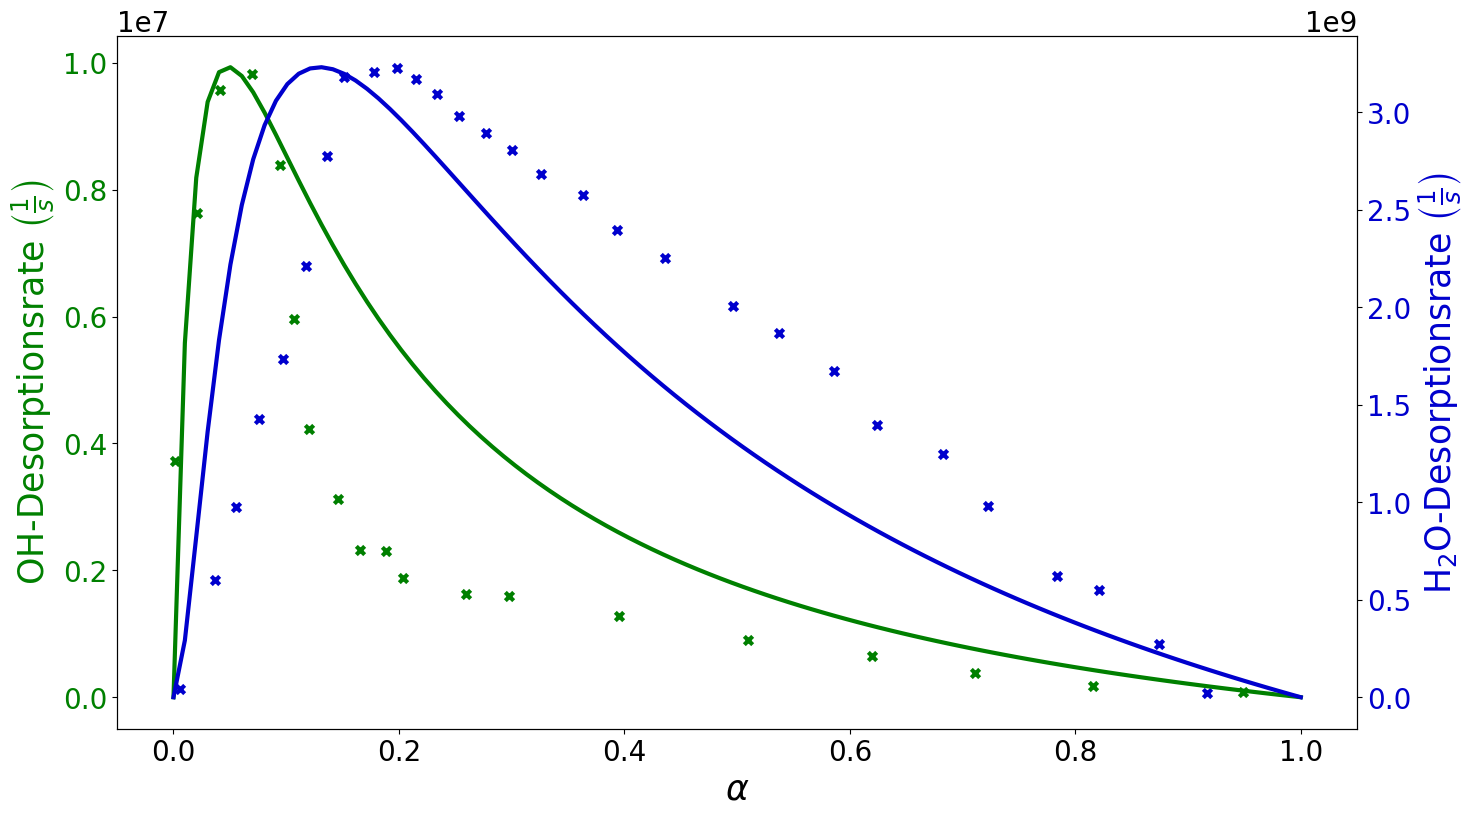

In [11]:
OH_d_rate=(conc[:,-1,4]-conc[:,-2,4])/0.6
H2O_d_rate=(conc[:,-1,5]-conc[:,-2,5])/0.6
des_data=np.loadtxt("./Hellsing_desorption.txt")  #[0:19] OH x-values, [19:38] OH y-values, [38:67] H2O x-values, [67:96] H2O y-values

plt.rc("lines", lw=3)
plt.rc("font", size=20)
fig, ax1=plt.subplots(figsize=(16,9))
ax1.set_xlabel(r"$\alpha$", fontsize=25)
ax1.set_ylabel(r"OH-Desorptionsrate $\left(\frac{1}{s}\right)$", color="green", fontsize=25)
ax1.plot(alpha_array,OH_d_rate, color="green")
ax1.scatter(des_data[0:19], des_data[19:38]*max(OH_d_rate),color="green",lw=3,label="Experimentelle Werte OH",marker="x")
ax1.scatter(des_data[38:67], des_data[67:96]*max(OH_d_rate),color="mediumblue",lw=3,label="Experimentelle Werte H$_2$O",marker="x")
plt.yticks(color="green")
ax2=ax1.twinx()
ax2.set_ylabel(r"H$_2$O-Desorptionsrate $\left(\frac{1}{s}\right)$", color="mediumblue", fontsize=25)
ax2.plot(alpha_array,H2O_d_rate, color="mediumblue")
plt.yticks(color="mediumblue")
plt.show()

In [13]:
#temperature dependance
#parameters
alpha_var=False             #always False except for Desorption vs. alpha
T=np.linspace(321,422,100)  #temperature in K
curden=10800                #current density in A/m²
P_cat=6.7e5                 #cathode pressure in Pa
P_an=6.7e5                  #anode pressure in Pa
h_memb=183e-5               #membrane thickness in m
h_cat=10e-6                 #cathode thickness in m
h_an=10e-6                  #anode thickness in m
c_COOH=1.17                 #concentration of COOH-endgroups in mol/l

#function execution
# 1. creating a list for each set of parameters
attack_rate1=[]
attack_rate2=[]
attack_rate3=[]
attack_rate4=[]
attack_rate5=[]
attack_rate6=[]
# 2. running the function deg_rate() with each set of parameters; the function only takes single values not lists or arrays, therefore this loop
i=0
while i<len(T):
    surf_reac=False
    attack_rate1.append(deg_rate(T[i],curden,P_cat,P_an,h_memb,1.5,1)[0])
    attack_rate2.append(deg_rate(T[i],curden,P_cat,P_an,h_memb,1.0,1)[0])
    attack_rate3.append(deg_rate(T[i],curden,P_cat,P_an,h_memb,0.0,1)[0])
    surf_reac=True
    attack_rate4.append(deg_rate(T[i],curden,P_cat,P_an,h_memb,1,0.4)[0])
    attack_rate5.append(deg_rate(T[i],curden,P_cat,P_an,h_memb,1,0.2)[0])
    attack_rate6.append(deg_rate(T[i],curden,P_cat,P_an,h_memb,1,0.0)[0])
    clear_output(wait=True)
    print(i)
    i+=1
# 3. converting the lists to np.arrays for better handling
attack_rate1=np.array(attack_rate1)
attack_rate2=np.array(attack_rate2)
attack_rate3=np.array(attack_rate3)
attack_rate4=np.array(attack_rate4)
attack_rate5=np.array(attack_rate5)
attack_rate6=np.array(attack_rate6)

99


[6.42486446e-07 3.99895770e-09]
1.4591107639746676e-08 1.3626077812022163e-10


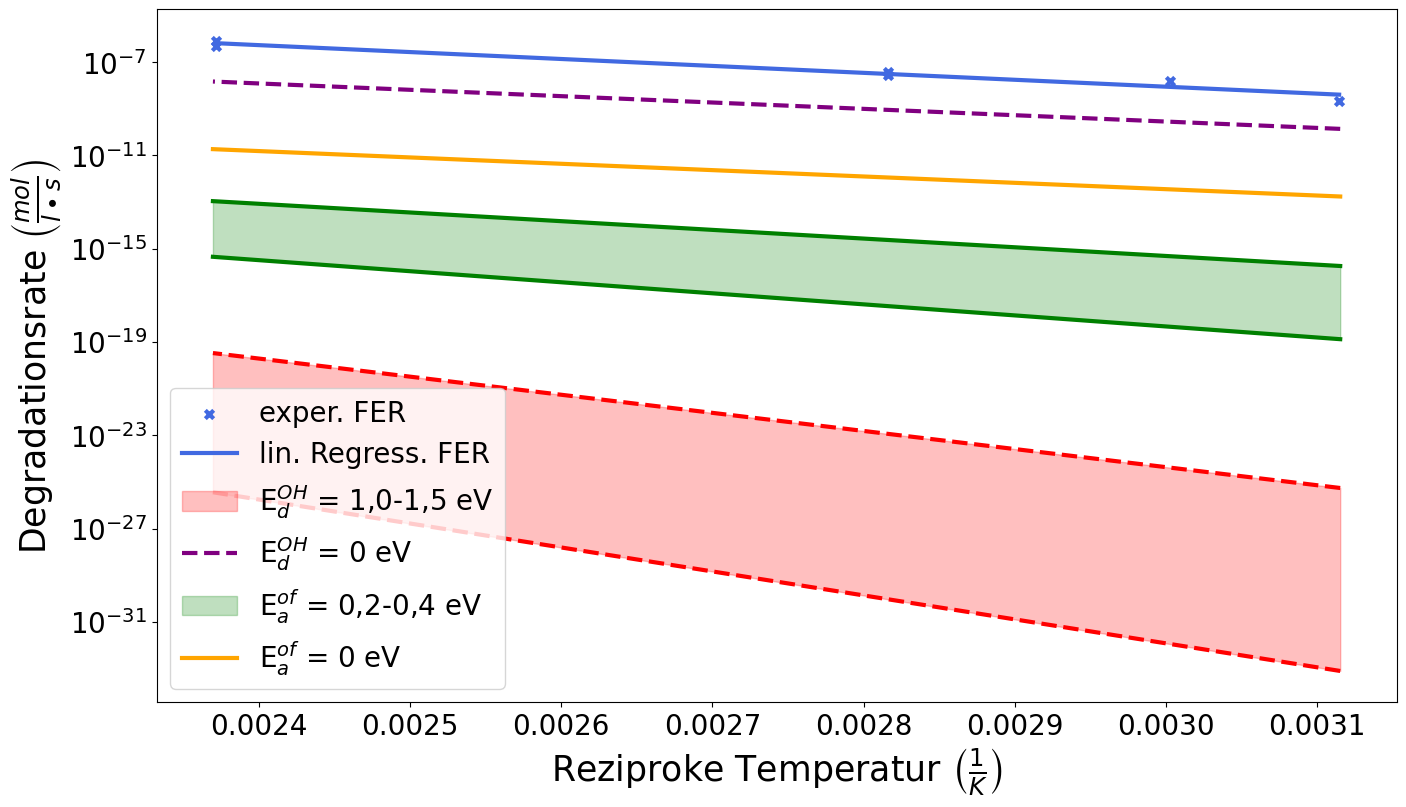

In [14]:
print(FER_data[14:16])
print(attack_rate3[-1],attack_rate3[0])

plt.figure(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.scatter(FER_data[0:6],FER_data[6:12], color="royalblue", marker="x", label="exper. FER")
plt.plot(FER_data[12:14],FER_data[14:16], color="royalblue", label="lin. Regress. FER")
plt.fill_between(1/T,attack_rate1,attack_rate2,color="red",alpha=.25, label="E$_d^{OH}$ = 1,0-1,5 eV")
plt.plot(1/T,attack_rate1, color="red", ls="dashed")
plt.plot(1/T,attack_rate2, color="red", ls="dashed")
plt.plot(1/T,attack_rate3, color="purple", ls="dashed", label="E$_d^{OH}$ = 0 eV")
plt.fill_between(1/T,attack_rate4,attack_rate5,color="green",alpha=.25, label="E$_a^{of}$ = 0,2-0,4 eV")
plt.plot(1/T,attack_rate4, color="green")
plt.plot(1/T,attack_rate5, color="green")
plt.plot(1/T,attack_rate6, color="orange", label="E$_a^{of}$ = 0 eV")
plt.ylabel(r"Degradationsrate $\left(\frac{mol}{l \bullet s}\right)$", fontsize=25)
plt.xlabel(r"Reziproke Temperatur $\left(\frac{1}{K}\right)$", fontsize=25)
plt.legend(loc="lower left")
plt.yscale("log")
plt.show()